 RECURRENT NEURAL NETWORK:

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
mmp=pd.read_csv('/content/monthly_milk_production.csv')

In [4]:
mmp

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [5]:
mmp.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [6]:
mmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [7]:
mmp.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [8]:
mmp.shape

(168, 2)

In [10]:
print(mmp.columns)

Index(['Date', 'Production'], dtype='object')


In [11]:
mmp['Date'] = pd.to_datetime(mmp['Date'])
mmp.set_index("Date",inplace=True)

Visualization:

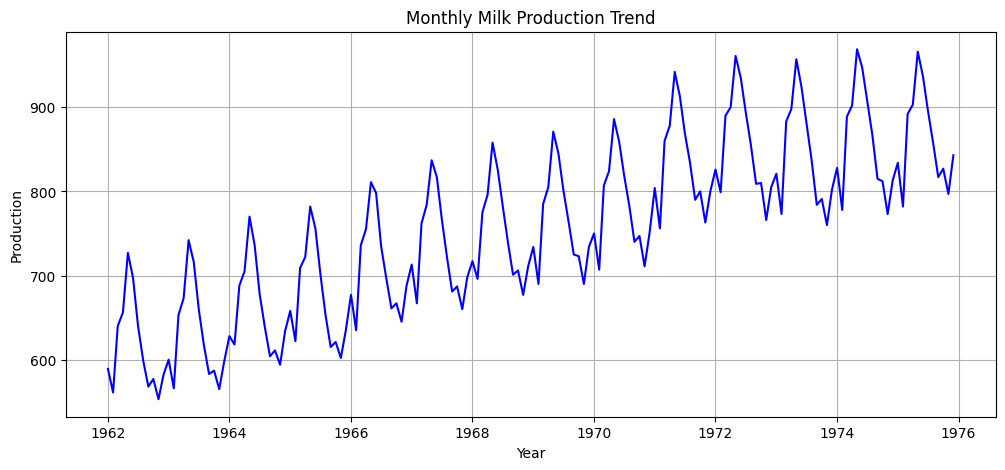

In [13]:
plt.figure(figsize=(12,5))
plt.plot(mmp.index, mmp['Production'], color='blue')
plt.title("Monthly Milk Production Trend")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid()
plt.show()

In [14]:
#Observations:

#Strong upward trend

#Clear seasonality

#No major anomalies

Scaling :

In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(mmp[['Production']])

Data Preparation for Deep Learning :

Create Time Series Sequences :

Train-Test Split :

In [16]:
import numpy as np

def create_sequences(data, seq_length):
    data = np.asarray(data)
    if data.ndim == 1:
        data = data.reshape(-1, 1)
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

In [17]:
X, y = create_sequences(scaled_data, seq_length=24)

In [18]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [19]:
X_train.shape

(115, 24, 1)

Step 5: Model Building

Evaluation Metrics Function

In [20]:
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mae, mape

Basic RNN Model :

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping


WINDOW_SIZE = 24

In [22]:
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')

rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0750 - val_loss: 0.0229
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0284 - val_loss: 0.0740
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0160 - val_loss: 0.0176
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0101 - val_loss: 0.0213
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0075 - val_loss: 0.0073
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0061 - val_loss: 0.0067
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0039 - val_loss: 0.0045
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0029 - val_loss: 0.0042
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0023 - val_loss: 0.0035
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021 - val_loss: 0.0027
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0019 - val_loss: 0.0030
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0017 - val_loss: 0.0025
Epoch 13/50


LSTM Model :

In [23]:
from tensorflow.keras.layers import LSTM

In [24]:
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.1819 - val_loss: 0.1477
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0462 - val_loss: 0.0413
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0344 - val_loss: 0.0253
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0248 - val_loss: 0.0322
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0274 - val_loss: 0.0249
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0245 - val_loss: 0.0222
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0238 - val_loss: 0.0214
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0233 - val_loss: 0.0213
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0230 - val_loss: 0.0212
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0227 - val_loss: 0.0209
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0227 - val_loss: 0.0208
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0228 - val_loss: 0.0208
E

GRU Model:

In [25]:
from tensorflow.keras.layers import GRU

In [26]:
gru_model = Sequential([
    GRU(50, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')

gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.1560 - val_loss: 0.1471
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0443 - val_loss: 0.0260
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0339 - val_loss: 0.0264
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0315 - val_loss: 0.0236
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0253 - val_loss: 0.0336
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0251 - val_loss: 0.0324
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0237 - val_loss: 0.0259
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0235 - val_loss: 0.0210
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0226 - val_loss: 0.0227
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0219 - val_loss: 0.0254
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0217 - val_loss: 0.0239
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0208 - val_loss: 0.0235
E

Model Evaluation :

Predictions :

In [27]:
rnn_pred = scaler.inverse_transform(rnn_model.predict(X_test))
lstm_pred = scaler.inverse_transform(lstm_model.predict(X_test))
gru_pred = scaler.inverse_transform(gru_model.predict(X_test))

y_test_actual = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


Metrics Comparison :

In [28]:
from sklearn.metrics import mean_absolute_error

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

models = {
    "RNN": rnn_pred,
    "LSTM": lstm_pred,
    "GRU": gru_pred
}

results = {}

for name, pred in models.items():
    results[name] = evaluate_model(y_test_actual, pred)

results_df = pd.DataFrame(results, index=["RMSE", "MAE", "MAPE"]).T
results_df

,RMSE,MAE,MAPE
RNN,17.093273,13.970823,1.670959
LSTM,66.646791,59.044905,7.151923
GRU,59.444021,50.059558,6.038385


Actual vs Predicted Plot :

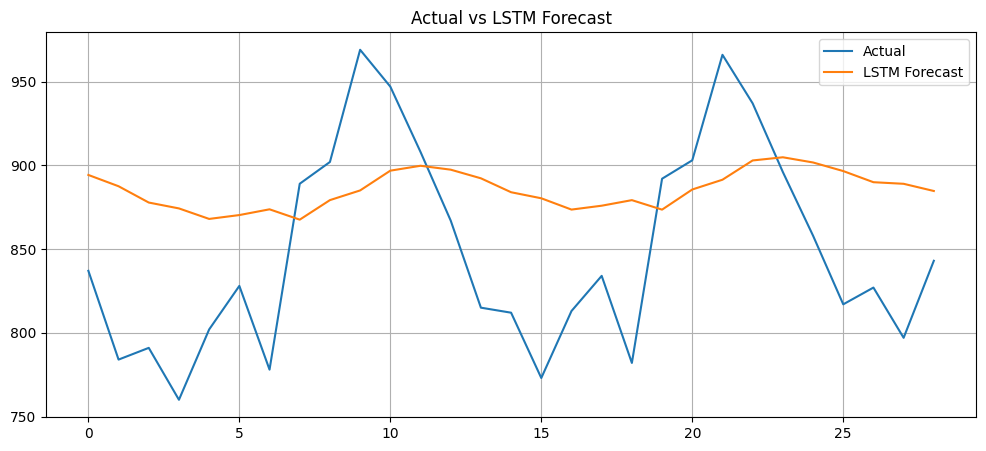

In [31]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(lstm_pred, label='LSTM Forecast')
plt.legend()
plt.title("Actual vs LSTM Forecast")
plt.grid()
plt.show()

Forecast Next 12 Months :

In [32]:
def forecast_future(model, data, steps=12):
    input_seq = data[-WINDOW_SIZE:]
    forecasts = []

    for _ in range(steps):
        pred = model.predict(input_seq.reshape(1, WINDOW_SIZE, 1))
        forecasts.append(pred[0,0])
        input_seq = np.append(input_seq[1:], pred, axis=0)

    return scaler.inverse_transform(np.array(forecasts).reshape(-1,1))

future_12_months = forecast_future(lstm_model, scaled_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


Visualization

/tmp/ipykernel_7503/1426883402.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(mmp.index[-1], periods=13, freq='M')[1:]


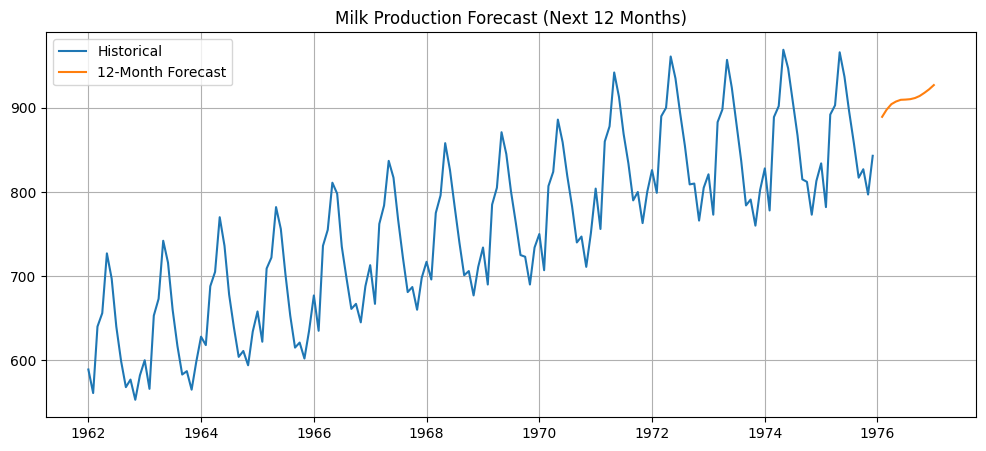

In [34]:
plt.figure(figsize=(12,5))
plt.plot(mmp.index, mmp['Production'], label='Historical')
future_dates = pd.date_range(mmp.index[-1], periods=13, freq='M')[1:]
plt.plot(future_dates, future_12_months, label='12-Month Forecast')
plt.legend()
plt.title("Milk Production Forecast (Next 12 Months)")
plt.grid()
plt.show()

Business Insights & Recommendations :

In [ ]:
#Model Performance Summary
#Model	               Performance
#RNN	Struggles with long-term dependencies
#GRU	Good balance of speed and accuracy
#LSTM	Best accuracy & seasonality capture

Key Business Insights :

In [35]:
#Seasonality Identified :

#Higher milk production in specific months
#Planning feed, workforce & logistics becomes easier

#Demand-Supply Alignment:
#Prevents overproduction and wastage
#Ensures steady supply to distributors

#Inventory Optimization

#Cold storage planning based on forecasts
#Reduced storage costs

#Strategic Growth

#Forecast trends support expansion decisions
#Early detection of declining production